In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.research_config import ResearchConfig
from src.data_helpers import write_json


# 08 Drawdown Diagnostics

Diagnose the saved portfolio’s drawdown and realized trade outcomes. No model parameters or trading rules are refitted.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [ ]:
cfg = ResearchConfig().validate()


## 2. Load saved portfolio and exact drawdown

Include the initial-capital reference in the running peak.


peak_date       2025-04-10 00:00:00
trough_date     2025-09-16 00:00:00
max_drawdown              -0.594387
dtype: object

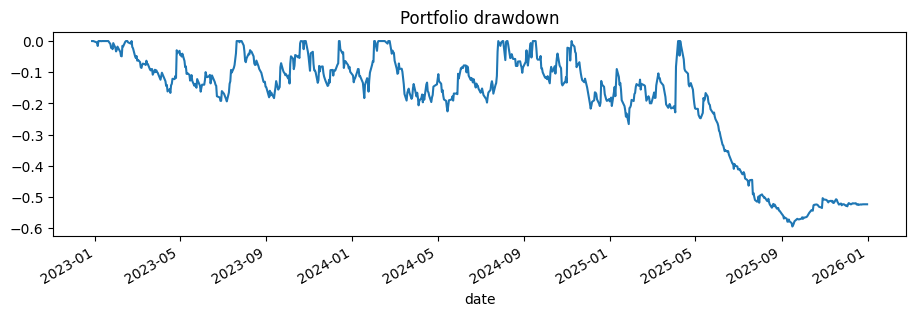

In [2]:
trades = pd.read_parquet("trades.parquet")
equity = pd.read_parquet("equity_curve.parquet")
running_peak = equity.equity.cummax().clip(lower=cfg.initial_capital)
drawdown = equity.equity / running_peak - 1
trough = drawdown.idxmin()
peak = equity.loc[:trough, "equity"].idxmax()
drawdown.to_frame("drawdown").to_parquet("drawdown_series.parquet")
write_json(
    "drawdown_episode.json",
    {"peak_date": peak, "trough_date": trough, "max_drawdown": drawdown.min()},
)
display(
    pd.Series(
        {"peak_date": peak, "trough_date": trough, "max_drawdown": drawdown.min()}
    )
)
drawdown.plot(figsize=(11, 3), title="Portfolio drawdown")
plt.show()


## 3. Worst days and loss clustering

Daily changes include option marks. Exit-date realized PnL is a different quantity.


In [3]:
daily_changes = equity.equity.diff().to_frame("equity_change")
display(daily_changes.nsmallest(10, "equity_change"))
if not trades.empty:
    losses_by_exit = trades.groupby("exit_date").pnl.sum().to_frame("realized_pnl")
    losses_by_exit.to_parquet("pnl_by_exit_date.parquet")
    display(losses_by_exit.nsmallest(10, "realized_pnl"))
else:
    print("No completed trades.")


,equity_change
date,
2024-08-05,-12769.116659
2025-07-22,-12032.588260
2025-04-09,-11524.400174
2024-10-24,-10777.449688
2024-11-14,-10228.309233
2024-09-11,-9866.703465
2024-08-12,-9305.520053
2025-04-22,-9142.860803
2025-04-14,-8838.459030


,realized_pnl
exit_date,
2024-06-26,-15700.616854
2025-02-28,-10408.173014
2025-03-24,-10135.116063
2025-06-12,-9823.765298
2025-09-30,-9597.419486
2024-12-31,-9433.647201
2025-04-08,-9402.934590
2025-02-07,-9366.233172
2025-08-27,-9245.914733


## 4. Pair performance and drawdown episode

Trade PnL for positions overlapping the episode is full-trade PnL, not an exact attribution of mark-to-market loss within the episode.


,n_trades,total_pnl,mean_trade_return,win_rate
pair,,,,
SPGI-ZTS,6,-21607.099557,-0.462746,0.166667
CHD-MKC,5,-19837.400371,-0.527792,0.200000
MCO-ZTS,2,-13417.677375,-0.963302,0.000000
DOV-EXPD,5,-11785.890906,-0.311800,0.200000
LRCX-TER,2,-11274.910029,-0.738979,0.000000
ADBE-DPZ,1,-9823.765298,-1.000000,0.000000
IQV-TECH,2,-9549.976535,-0.781776,0.000000
NTRS-PNC,7,-9494.980141,-0.312580,0.428571
ICE-MCO,3,-8912.757055,-0.373751,0.333333


,pair,entry_date,exit_date,pnl,trade_return
125,CHD-MKC,2024-09-20,2025-03-24,-10135.116063,-1.000000
115,CMS-ETR,2024-09-26,2025-02-07,-10094.782211,-1.000000
134,ADBE-DPZ,2025-01-15,2025-06-12,-9823.765298,-1.000000
149,ABT-ZTS,2025-04-09,2025-09-30,-9597.419486,-1.000000
110,AEP-ETR,2024-10-07,2024-12-31,-9433.647201,-1.000000
128,ABT-ZTS,2024-12-23,2025-04-08,-9402.934590,-1.000000
147,ARE-CCI,2025-03-12,2025-08-27,-9245.914733,-1.000000
117,LRCX-TER,2024-09-03,2025-02-28,-9137.346751,-1.000000
130,SPGI-ZTS,2024-11-13,2025-05-07,-8728.815034,-0.943879
148,DUK-WM,2025-03-17,2025-09-02,-8476.055951,-1.000000


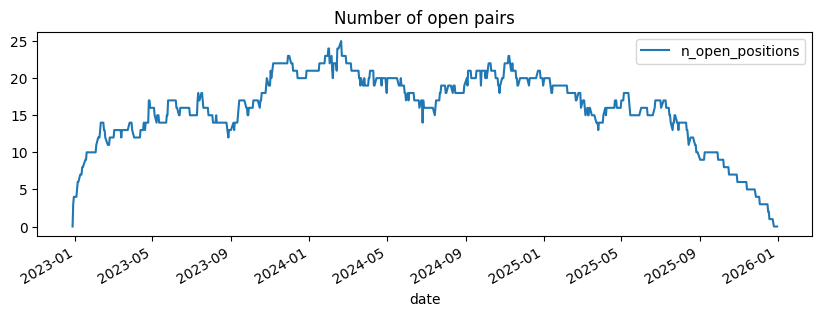

In [4]:
if not trades.empty:
    pair_performance = trades.groupby("pair").agg(
        n_trades=("pnl", "size"),
        total_pnl=("pnl", "sum"),
        mean_trade_return=("trade_return", "mean"),
        win_rate=("pnl", lambda x: (x > 0).mean()),
    )
    overlapping = trades.loc[
        (trades.entry_date <= trough) & (trades.exit_date >= peak)
    ].copy()
    pair_performance.to_parquet("pair_performance.parquet")
    overlapping.to_parquet("drawdown_overlapping_trades.parquet")
    display(pair_performance.sort_values("total_pnl").head(15))
    display(
        trades.nsmallest(10, "pnl")[
            ["pair", "entry_date", "exit_date", "pnl", "trade_return"]
        ]
    )
equity[["n_open_positions"]].plot(figsize=(10, 3), title="Number of open pairs")
plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.
